<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/intro_to_sklearn_command.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report


In [ ]:
# loading the data
data = load_iris()
features = data["data"]
feature_names = data["feature_names"]
label = data["target"]
label_names = data["target_names"]

In [ ]:
# making a dictionary or dataframe
dic = {}

for i in feature_names:
  dic[i] = 0
dic["label"] = 0

sepel_length = []
sepel_width = []
petal_length = []
petal_width = []

for i in range(len(features)):
  for j in range(len(features[i])):
    if j == 0:
      sepel_length.append(features[i][j])
    elif j == 1:
        sepel_width.append(features[i][j])
    elif j == 2:
        petal_length.append(features[i][j])
    elif j ==3:
        petal_width.append(features[i][j])

label = label.tolist()

dic["sepal length (cm)"] = sepel_length
dic["sepal width (cm)"] = sepel_width
dic["petal length (cm)"] = petal_length
dic["petal width (cm)"] = petal_width
dic["label"] = label


In [ ]:
df = pd.DataFrame(dic)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   label              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


<Axes: >

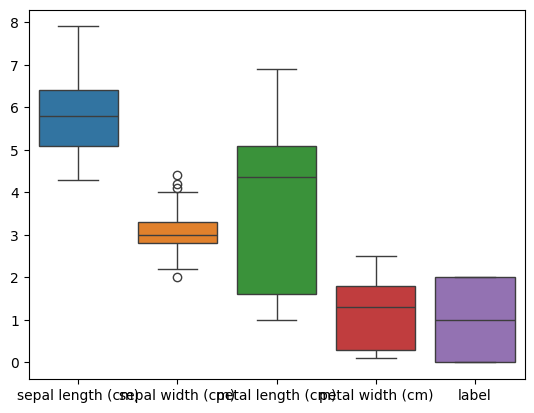

In [ ]:
sns.boxplot(df)

In [ ]:
# removing outliers
Q1 = df["sepal width (cm)"].quantile(0.25)
Q3 = df["sepal width (cm)"].quantile(0.75)
iqr = Q3-Q1
lb = Q1-1.5*iqr
ub = Q3+1.5*iqr
df1 = df[(df["sepal width (cm)"] > lb) & (df["sepal width (cm)"] < ub)]

<Axes: >

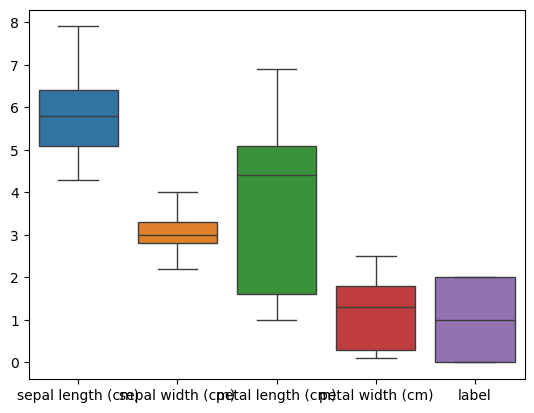

In [ ]:
sns.boxplot(df1)

/tmp/ipython-input-2128019508.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["sepal length (cm)"])


<Axes: xlabel='sepal length (cm)', ylabel='Density'>

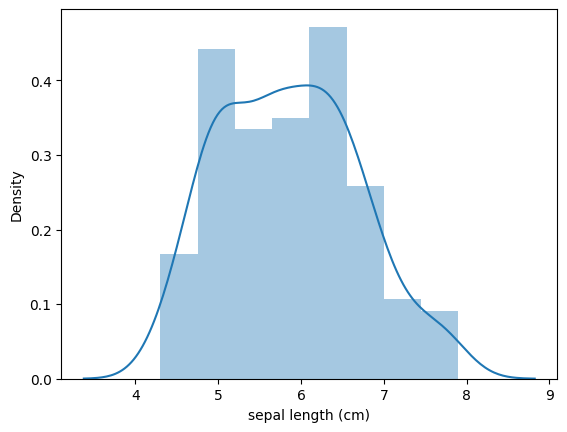

In [ ]:
sns.distplot(df1["sepal length (cm)"])

/tmp/ipython-input-689090166.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["sepal width (cm)"])


<Axes: xlabel='sepal width (cm)', ylabel='Density'>

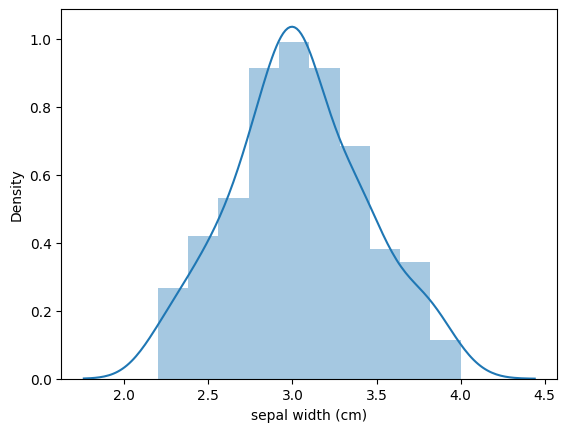

In [ ]:
sns.distplot(df1["sepal width (cm)"])

/tmp/ipython-input-977188597.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["petal length (cm)"])


<Axes: xlabel='petal length (cm)', ylabel='Density'>

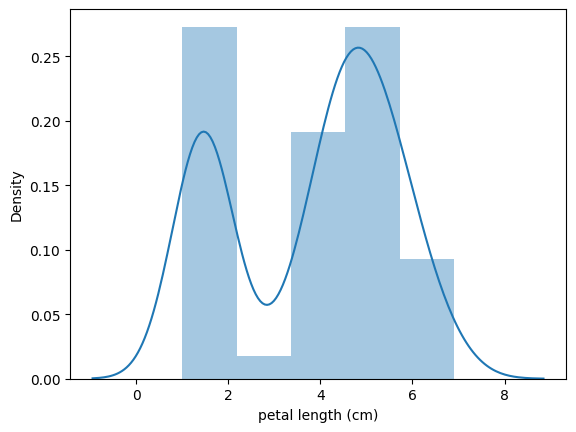

In [ ]:
sns.distplot(df1["petal length (cm)"])

/tmp/ipython-input-114947628.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["petal width (cm)"])


<Axes: xlabel='petal width (cm)', ylabel='Density'>

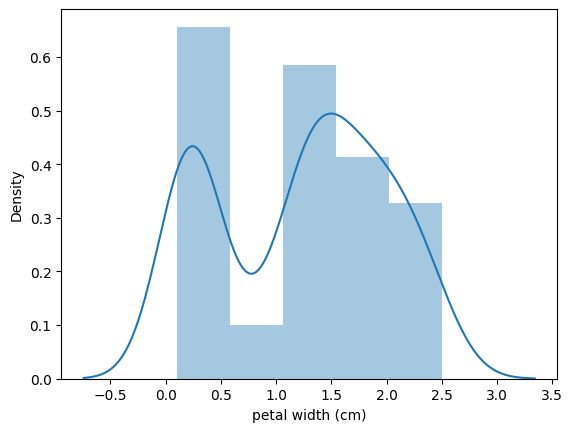

In [ ]:
sns.distplot(df1["petal width (cm)"])

In [ ]:
# spliting x and y
x = df1.drop(columns = ["label"])
y = df1["label"]

In [ ]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size = 0.2 , random_state = 432)# we are spliting the data

In [ ]:
# noprmalizing the data
# fit is to train and transform is to transform the data range
normalizer = MinMaxScaler()

x_train_normalize = normalizer.fit_transform(xtrain)


In [ ]:
# converting array into list of normalize data and changing the scale
dic_features_normalize = {
    "sepel length (cm)" : 0,
    "sepel width (cm)" : 0,
    "petal width (cm)" : 0,
    "petal length (cm)" : 0,
}
sepel_length = []
sepel_width = []
petal_length = []
petal_width = []

for i in range(len(x_train_normalize)):
  for j in range(len(x_train_normalize[i])):
    if j == 0:
      sepel_length.append(x_train_normalize[i][j])
    elif j ==1:
      sepel_width.append(x_train_normalize[i][j])
    elif j ==2:
      petal_length.append(x_train_normalize[i][j])
    else:
      petal_width.append(x_train_normalize[i][j])

dic_features_normalize["sepel length (cm)"] = sepel_length
dic_features_normalize["sepel width (cm)"] = sepel_width
dic_features_normalize["petal length (cm)"] = petal_length
dic_features_normalize["petal width (cm)"] = petal_width

df_features_normalize = pd.DataFrame(dic_features_normalize)
df_features_normalize

,sepel length (cm),sepel width (cm),petal width (cm),petal length (cm)
0,0.676471,0.388889,0.500000,0.610169
1,0.382353,0.277778,0.500000,0.542373
2,0.441176,0.222222,0.458333,0.508475
3,0.470588,0.444444,0.708333,0.694915
4,0.294118,0.833333,0.041667,0.084746
...,...,...,...,...
111,0.323529,0.944444,0.125000,0.050847
112,0.588235,0.611111,1.000000,0.847458
113,0.617647,0.277778,0.750000,0.728814
114,0.617647,0.333333,0.875000,0.779661


/tmp/ipython-input-2159392785.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_features_normalize["sepel width (cm)"])


<Axes: xlabel='sepel width (cm)', ylabel='Density'>

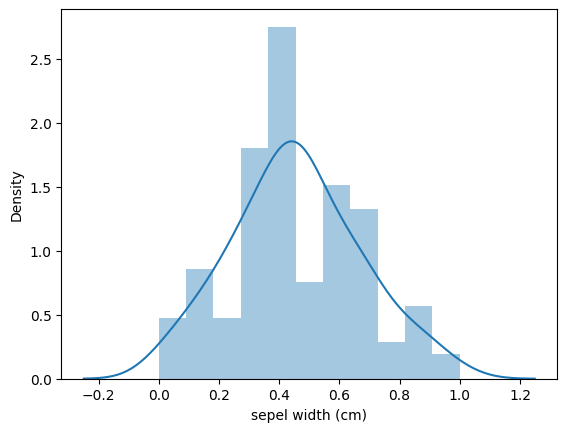

In [ ]:
sns.distplot(df_features_normalize["sepel width (cm)"])

In [ ]:
# fit is to train the data
model = LogisticRegression()
model.fit(x_train_normalize , ytrain)

LogisticRegression()

In [ ]:
# we dont need to use fit again because normalzer know the data range so we only need to transform the data
xtest_normalize = normalizer.transform(xtest)

In [ ]:
ypredict =  model.predict(xtest_normalize)

In [ ]:
ypredict

array([1, 2, 0, 0, 0, 2, 1, 1, 2, 0, 0, 2, 1, 0, 1, 2, 1, 0, 1, 0, 2, 2,
       0, 0, 2, 0, 1, 1, 2, 2])

In [ ]:
print(classification_report(ytest , ypredict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.89      1.00      0.94         8
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
confusion_matrix(ytest , ypredict)

array([[11,  0,  0],
       [ 0,  8,  0],
       [ 0,  1, 10]])

**We are using standardscale from here**

In [ ]:
standardizer = StandardScaler()
xtrain_standardize = standardizer.fit_transform(xtrain)

In [ ]:
# fit is to train the data
model1 = LogisticRegression()
model1.fit(xtrain_standardize , ytrain)

LogisticRegression()

In [ ]:
# we dont need to use fit again because normalzer know the data range so we only need to transform the data
xtest_standardize = standardizer.transform(xtest)

In [ ]:
ypredict1 = model1.predict(xtest_standardize)
ypredict1

array([1, 2, 0, 0, 0, 2, 1, 1, 2, 0, 0, 2, 1, 0, 1, 2, 1, 0, 1, 0, 2, 2,
       0, 0, 2, 0, 1, 1, 2, 2])

In [ ]:
confusion_matrix(ytest,ypredict1)

array([[11,  0,  0],
       [ 0,  8,  0],
       [ 0,  1, 10]])

In [ ]:
classification_report(ytest , ypredict1)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        11\n           1       0.89      1.00      0.94         8\n           2       1.00      0.91      0.95        11\n\n    accuracy                           0.97        30\n   macro avg       0.96      0.97      0.96        30\nweighted avg       0.97      0.97      0.97        30\n'